In [81]:
import torch
import torch.nn as nn
from torch.optim import Adam
from torchvision import transforms
from torch.utils.data import DataLoader, Dataset
from torchvision import models
from sklearn.preprocessing import LabelEncoder
import pandas as pd
from PIL import Image
import os
import numpy as np
import matplotlib.pyplot as plt

In [82]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [83]:
train_df = pd.read_csv('train/train.csv')
val_df = pd.read_csv('train/val.csv')

In [84]:
train_df["category"].unique()

array([0, 1, 2])

In [85]:
transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.ConvertImageDtype(torch.float)
])

In [86]:
class CustomImageDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe
        self.transform = transform
        self.labels = torch.tensor(dataframe["category"]).to(device)

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        img_path = self.dataframe.iloc[idx,0]
        label = self.labels[idx]
        image = Image.open(img_path)

        if self.transform:
            image = (self.transform(image)/255.0).to(device)
        return image, label

In [87]:
train_dataset = CustomImageDataset(train_df, transform=transform)
val_dataset = CustomImageDataset(val_df, transform=transform)

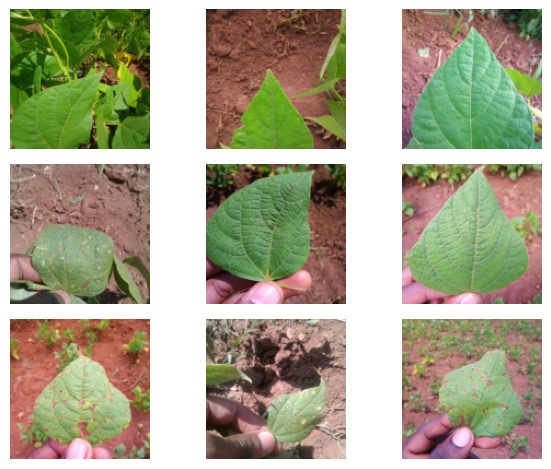

In [88]:
n_rows = 3
n_cols = 3

f, axarr = plt.subplots(n_rows,n_cols)

for row in range(n_rows):
    for col in range(n_cols):
        image = train_dataset[np.random.randint(0, len(train_dataset))][0].detach().cpu()
        image = image.squeeze(0) if image.shape[0] == 1 else image.permute(1, 2, 0)
        axarr[row, col].imshow((image * 255.0).numpy())
        axarr[row, col].axis("off")

plt.tight_layout()
plt.show()

In [89]:
LR = 1e-3
BATCH_SIZE = 4
EPOCH = 15

In [90]:
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=True)

In [91]:
googlenet_model = models.googlenet(weights="DEFAULT")

In [92]:

for param in googlenet_model.parameters():
    param.requires_grad = True
    

In [93]:
googlenet_model.fc

Linear(in_features=1024, out_features=1000, bias=True)

In [94]:
num_classes = len(train_df["category"].unique())

num_classes

3

In [95]:
googlenet_model.fc = torch.nn.Linear(googlenet_model.fc.in_features, num_classes)
googlenet_model.fc

Linear(in_features=1024, out_features=3, bias=True)

In [96]:
googlenet_model.to(device)

GoogLeNet(
  (conv1): BasicConv2d(
    (conv): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn): BatchNorm2d(64, eps=0.001, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  )
  (maxpool1): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=True)
  (conv2): BasicConv2d(
    (conv): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
    (bn): BatchNorm2d(64, eps=0.001, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  )
  (conv3): BasicConv2d(
    (conv): Conv2d(64, 192, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn): BatchNorm2d(192, eps=0.001, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  )
  (maxpool2): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=True)
  (inception3a): Inception(
    (branch1): BasicConv2d(
      (conv): Conv2d(192, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn): BatchNorm2d(64, eps=0.001,

In [97]:
loss_fun = nn.CrossEntropyLoss()
optimizer = Adam(googlenet_model.parameters(), lr=LR)

total_loss_train_plot = []
total_acc_train_plot = []


for epoch in range(EPOCH):
    total_acc_train = 0
    total_loss_train= 0

    for inputs, labels in train_loader:
        optimizer.zero_grad()
        outputs = googlenet_model(inputs)
        train_loss = loss_fun(outputs, labels)
        total_loss_train+=train_loss.item()

        train_loss.backward()

        train_acc = (torch.argmax(outputs,axis=1)==labels).sum().item()
        total_acc_train+=train_acc

        optimizer.step()


    total_loss_train_plot.append(round(total_loss_train/1000,4))
    total_acc_train_plot.append(round(total_acc_train/train_dataset.__len__()*100,4))

    print(f"Epoch {epoch+1}/{EPOCH}, Train Loss : {round(total_loss_train/1000,4)}, Train Accuracy : {round(total_acc_train/train_dataset.__len__()*100,4)}")
    
    


Epoch 1/15, Train Loss : 0.2508, Train Accuracy : 53.9652
Epoch 2/15, Train Loss : 0.2166, Train Accuracy : 61.6054
Epoch 3/15, Train Loss : 0.2006, Train Accuracy : 65.6673
Epoch 4/15, Train Loss : 0.1891, Train Accuracy : 68.6654
Epoch 5/15, Train Loss : 0.1824, Train Accuracy : 70.3095
Epoch 6/15, Train Loss : 0.1662, Train Accuracy : 73.8878
Epoch 7/15, Train Loss : 0.1471, Train Accuracy : 79.0135
Epoch 8/15, Train Loss : 0.1397, Train Accuracy : 79.0135
Epoch 9/15, Train Loss : 0.1416, Train Accuracy : 78.9168
Epoch 10/15, Train Loss : 0.137, Train Accuracy : 79.207
Epoch 11/15, Train Loss : 0.1162, Train Accuracy : 81.8182
Epoch 12/15, Train Loss : 0.1035, Train Accuracy : 85.2998
Epoch 13/15, Train Loss : 0.105, Train Accuracy : 84.236
Epoch 14/15, Train Loss : 0.114, Train Accuracy : 84.1393
Epoch 15/15, Train Loss : 0.0998, Train Accuracy : 86.0735


In [98]:
with torch.no_grad():

    total_loss_test = 0

    total_acc_test = 0



    for inputs, labels in val_loader:

        prediction = googlenet_model(inputs)



        test_acc = (torch.argmax(prediction,axis=1)==labels).sum().item()

        total_acc_test += test_acc

In [100]:
print("total_loss_test:-",(round(total_loss_test/1000,4)))
print("total_acc_test:-",{round(total_acc_test/val_dataset.__len__()*100,4)})


total_loss_test:- 0.0
total_acc_test:- {84.2105}


Transfer Learning

In [101]:
googlenet_model = models.googlenet(weights="DEFAULT")



for param in googlenet_model.parameters():
    param.requires_grad = False


googlenet_model.fc = torch.nn.Linear(googlenet_model.fc.in_features, num_classes)
googlenet_model.fc.requires_grad = True

googlenet_model.to(device)

GoogLeNet(
  (conv1): BasicConv2d(
    (conv): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn): BatchNorm2d(64, eps=0.001, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  )
  (maxpool1): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=True)
  (conv2): BasicConv2d(
    (conv): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
    (bn): BatchNorm2d(64, eps=0.001, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  )
  (conv3): BasicConv2d(
    (conv): Conv2d(64, 192, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn): BatchNorm2d(192, eps=0.001, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  )
  (maxpool2): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=True)
  (inception3a): Inception(
    (branch1): BasicConv2d(
      (conv): Conv2d(192, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn): BatchNorm2d(64, eps=0.001,

In [102]:
loss_fun = nn.CrossEntropyLoss()
optimizer = Adam(googlenet_model.parameters(), lr=LR)

total_loss_train_plot = []
total_acc_train_plot = []


for epoch in range(EPOCH):
    total_acc_train = 0
    total_loss_train= 0

    for inputs, labels in train_loader:
        optimizer.zero_grad()
        outputs = googlenet_model(inputs)
        train_loss = loss_fun(outputs, labels)
        total_loss_train+=train_loss.item()

        train_loss.backward()

        train_acc = (torch.argmax(outputs,axis=1)==labels).sum().item()
        total_acc_train+=train_acc

        optimizer.step()


    total_loss_train_plot.append(round(total_loss_train/1000,4))
    total_acc_train_plot.append(round(total_acc_train/train_dataset.__len__()*100,4))

    print(f"Epoch {epoch+1}/{EPOCH}, Train Loss : {round(total_loss_train/1000,4)}, Train Accuracy : {round(total_acc_train/train_dataset.__len__()*100,4)}")
    
    


Epoch 1/15, Train Loss : 0.2706, Train Accuracy : 46.0348
Epoch 2/15, Train Loss : 0.2431, Train Accuracy : 54.6422
Epoch 3/15, Train Loss : 0.2286, Train Accuracy : 58.8008
Epoch 4/15, Train Loss : 0.2392, Train Accuracy : 56.4797
Epoch 5/15, Train Loss : 0.2259, Train Accuracy : 60.2515
Epoch 6/15, Train Loss : 0.2183, Train Accuracy : 61.3153
Epoch 7/15, Train Loss : 0.2261, Train Accuracy : 61.0251
Epoch 8/15, Train Loss : 0.2154, Train Accuracy : 61.8956
Epoch 9/15, Train Loss : 0.2241, Train Accuracy : 60.1547
Epoch 10/15, Train Loss : 0.226, Train Accuracy : 59.5745
Epoch 11/15, Train Loss : 0.2199, Train Accuracy : 62.089
Epoch 12/15, Train Loss : 0.2087, Train Accuracy : 64.9903
Epoch 13/15, Train Loss : 0.2192, Train Accuracy : 61.0251
Epoch 14/15, Train Loss : 0.2114, Train Accuracy : 63.1528
Epoch 15/15, Train Loss : 0.2126, Train Accuracy : 63.5397


In [103]:
with torch.no_grad():

    total_loss_test = 0

    total_acc_test = 0



    for inputs, labels in val_loader:

        prediction = googlenet_model(inputs)



        test_acc = (torch.argmax(prediction,axis=1)==labels).sum().item()

        total_acc_test += test_acc


print("total_acc_test:-",round(total_acc_test/val_dataset.__len__()*100,4))

total_acc_test:- 62.406
